In [3]:
import mysql.connector
import pandas as pd

# Connexion à ta base MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="palworld_database"
)


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\2312779969.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


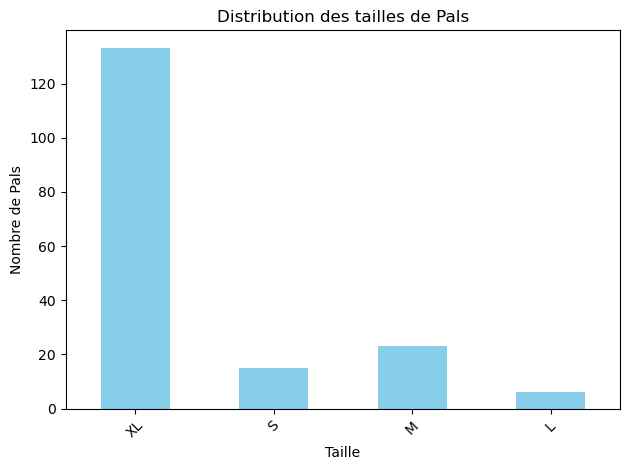

In [9]:
# a. Distribution de la taille des Pals

import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT size, COUNT(*) AS count
FROM hidden_attribute
WHERE size IS NOT NULL AND size != ''
GROUP BY size;
"""

df = pd.read_sql(query, conn)
df.plot(kind="bar", x="size", y="count", legend=False, color='skyblue')
plt.title("Distribution des tailles de Pals")
plt.ylabel("Nombre de Pals")
plt.xlabel("Taille")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\3096901576.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


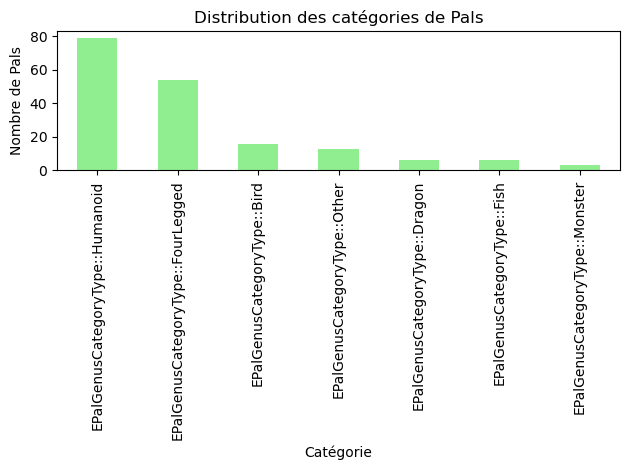

In [11]:
#  b. Distribution de la catégorie (genuscategory)

query = """
SELECT genuscategory, COUNT(*) AS count
FROM hidden_attribute
WHERE genuscategory IS NOT NULL AND genuscategory != ''
GROUP BY genuscategory
ORDER BY count DESC;
"""

df = pd.read_sql(query, conn)
df.plot(kind="bar", x="genuscategory", y="count", legend=False, color='lightgreen')
plt.title("Distribution des catégories de Pals")
plt.ylabel("Nombre de Pals")
plt.xlabel("Catégorie")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\1284741989.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


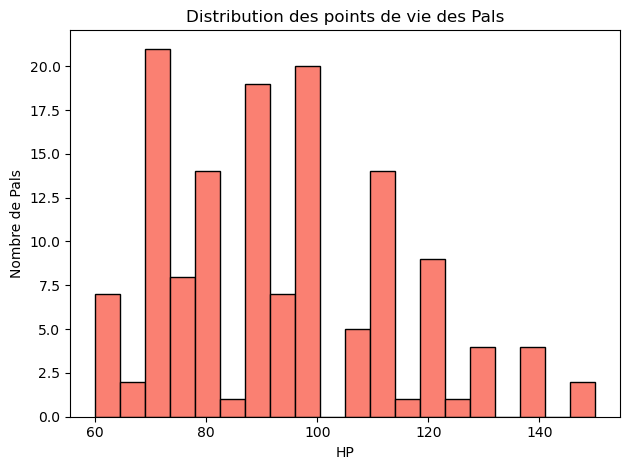

In [13]:
# c. Distribution des points de vie (HP)

query = "SELECT hp FROM combat_attribute WHERE hp IS NOT NULL AND hp > 0;"
df = pd.read_sql(query, conn)

plt.hist(df["hp"], bins=20, color='salmon', edgecolor='black')
plt.title("Distribution des points de vie des Pals")
plt.xlabel("HP")
plt.ylabel("Nombre de Pals")
plt.tight_layout()
plt.show()


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\1860394141.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


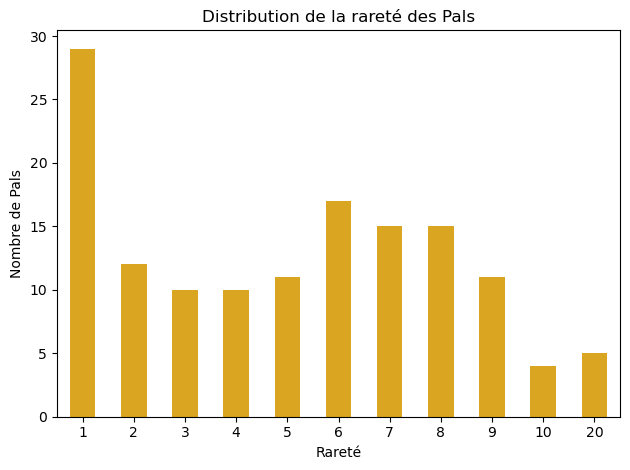

In [15]:
# d. Distribution de la rareté des Pals

query = """
SELECT rarity, COUNT(*) AS count
FROM combat_attribute
WHERE rarity IS NOT NULL AND rarity != ''
GROUP BY rarity
ORDER BY CAST(rarity AS UNSIGNED);
"""

df = pd.read_sql(query, conn)

df["rarity"] = df["rarity"].astype(str)  # s'assurer que c'est lisible

df.plot(kind="bar", x="rarity", y="count", legend=False, color="goldenrod")
plt.title("Distribution de la rareté des Pals")
plt.xlabel("Rareté")
plt.ylabel("Nombre de Pals")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\2153259228.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


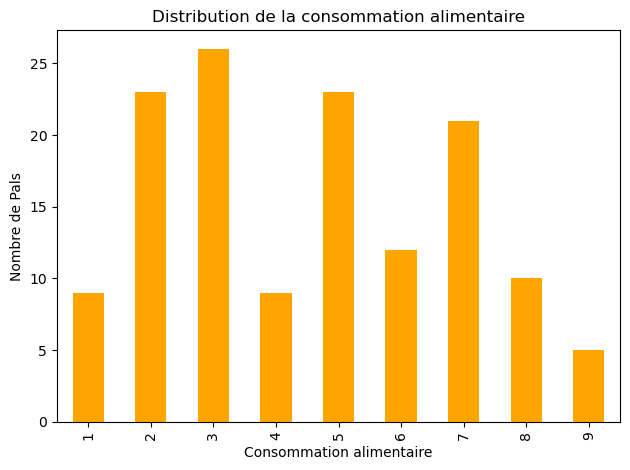

In [17]:
#  e. Distribution de la consommation alimentaire des Pals

query = """
SELECT food_intake, COUNT(*) AS count
FROM job_skill
WHERE food_intake IS NOT NULL
GROUP BY food_intake
ORDER BY food_intake;
"""
df = pd.read_sql(query, conn)

df.plot(kind="bar", x="food_intake", y="count", color="orange", legend=False)
plt.title("Distribution de la consommation alimentaire")
plt.xlabel("Consommation alimentaire")
plt.ylabel("Nombre de Pals")
plt.tight_layout()
plt.show()


In [19]:
# f. Pals utiles au ranch (laine, œuf, lait, etc.)

query = """
SELECT english_name, ranch_items
FROM job_skill
WHERE ranch_items IS NOT NULL AND ranch_items != '';
"""
df = pd.read_sql(query, conn)
display(df)


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\410627571.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,english_name,ranch_items
0,lamball,wool
1,chikipi,Egg
2,vixy,Palu Ball Advanced Palu Ball Arrow Gold Coin
3,cremis,wool
4,mau,gold
5,mau cryst,gold
6,mozzarina,milk
7,woolipop,Marshmallow
8,caprity,red wild berries
9,melpaca,wool


In [21]:
# g. Puissance de combat des Pals – top 10

query = """
SELECT name, hp, melee_attack, remote_attack, defense,
       (hp + melee_attack + remote_attack + defense) AS power_score
FROM combat_attribute
WHERE hp IS NOT NULL AND melee_attack IS NOT NULL AND remote_attack IS NOT NULL AND defense IS NOT NULL
ORDER BY power_score DESC
LIMIT 10;
"""
df = pd.read_sql(query, conn)
display(df)


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\511042866.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,name,hp,melee_attack,remote_attack,defense,power_score
0,Frostallion Noct,140,100,140,135,515
1,Shadowbeak,120,130,120,140,510
2,Jormuntide Ignis,130,150,130,100,510
3,Paladius,130,110,120,145,505
4,Jormuntide,130,150,120,100,500
5,Frostallion,140,100,140,120,500
6,Necromus,130,100,145,120,495
7,Blazamut,100,150,125,120,495
8,Anubis,120,130,130,100,480
9,Jetragon,110,100,140,110,460


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\2706025142.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


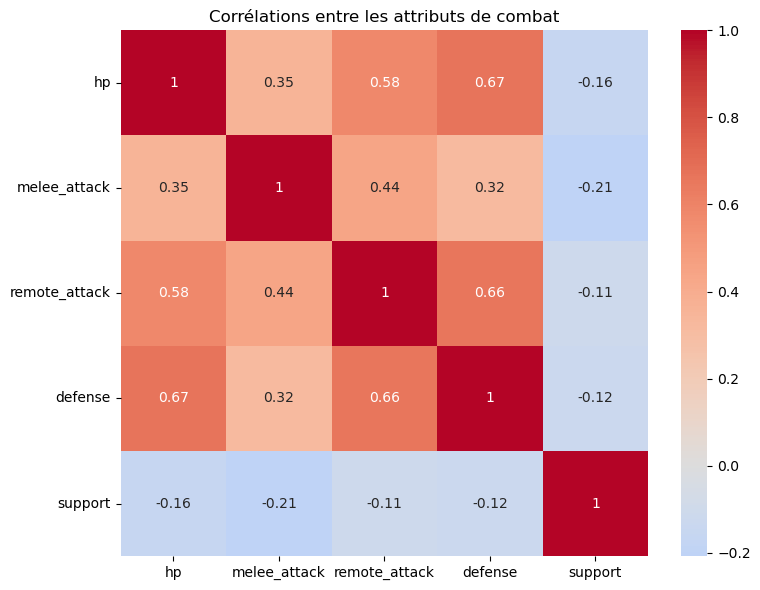

In [25]:
# h. Corrélations entre les attributs de combat

query = """
SELECT hp, melee_attack, remote_attack, defense, support
FROM combat_attribute
WHERE hp IS NOT NULL;
"""
df = pd.read_sql(query, conn)

corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Corrélations entre les attributs de combat")
plt.tight_layout()
plt.show()



C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\2781166391.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


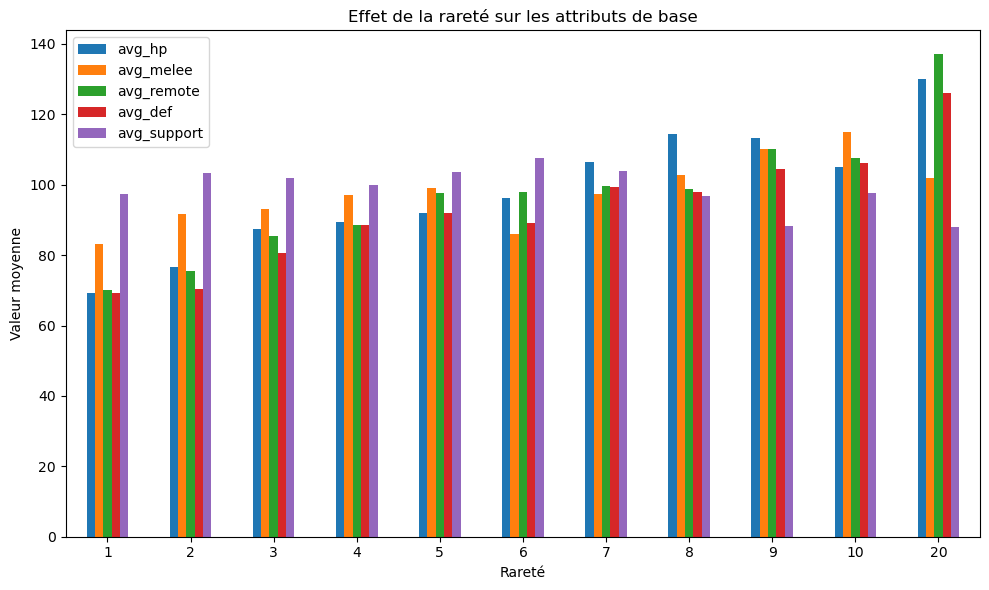

In [27]:
# i. Comment la rareté d'un Pal affecte-t-elle les valeurs de ses
# attributs de base ?

query = """
SELECT 
  rarity,
  AVG(hp) AS avg_hp,
  AVG(melee_attack) AS avg_melee,
  AVG(remote_attack) AS avg_remote,
  AVG(defense) AS avg_def,
  AVG(support) AS avg_support
FROM combat_attribute
WHERE rarity IS NOT NULL AND rarity != ''
GROUP BY rarity
ORDER BY CAST(rarity AS UNSIGNED);
"""

df = pd.read_sql(query, conn)

df.set_index("rarity").plot(kind="bar", figsize=(10, 6))
plt.title("Effet de la rareté sur les attributs de base")
plt.ylabel("Valeur moyenne")
plt.xlabel("Rareté")
plt.xticks(rotation=0)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [29]:
#  j. Quelle est la rareté moyenne des Pals ayant la puissance d’attaque la plus élevée ?

query = """
SELECT AVG(CAST(rarity AS UNSIGNED)) AS avg_rarity_top_attack
FROM (
    SELECT rarity
    FROM combat_attribute
    WHERE melee_attack IS NOT NULL AND rarity IS NOT NULL AND rarity != ''
    ORDER BY melee_attack DESC
    LIMIT 10
) AS top_attack_pals;
"""

df = pd.read_sql(query, conn)
print(f"🎯 Rareté moyenne des 10 Pals avec la plus haute attaque : {df.iloc[0, 0]:.2f}")


🎯 Rareté moyenne des 10 Pals avec la plus haute attaque : 7.30


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\3657091206.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\3703051970.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


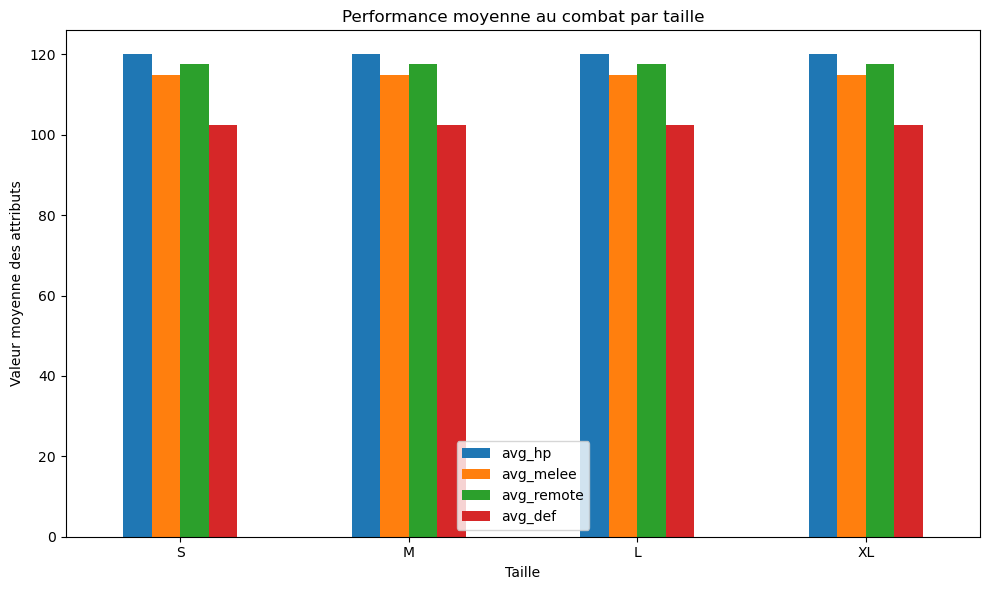

In [42]:
# k. La taille des Pals affecte-t-elle leur performance au combat ?

query = """
SELECT 
  h.size,
  AVG(c.hp) AS avg_hp,
  AVG(c.melee_attack) AS avg_melee,
  AVG(c.remote_attack) AS avg_remote,
  AVG(c.defense) AS avg_def
FROM hidden_attribute h
JOIN combat_attribute c ON name = codename
WHERE h.size IS NOT NULL AND h.size != ''
GROUP BY h.size
ORDER BY FIELD(h.size, 'XS', 'S', 'M', 'L', 'XL');
"""

df = pd.read_sql(query, conn)

df.set_index("size").plot(kind="bar", figsize=(10, 6))
plt.title("Performance moyenne au combat par taille")
plt.ylabel("Valeur moyenne des attributs")
plt.xlabel("Taille")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
# l. Les Pals les plus rapides sont-ils généralement plus efficaces au combat ?

query = """
SELECT 
  running_speed,
  hp,
  melee_attack,
  remote_attack,
  defense
FROM combat_attribute
WHERE running_speed IS NOT NULL AND hp IS NOT NULL;
"""
df = pd.read_sql(query, conn)

# Corrélations avec la vitesse
corr = df.corr(numeric_only=True)
print(corr["running_speed"])


running_speed    1.000000
hp               0.414545
melee_attack     0.311666
remote_attack    0.630859
defense          0.431195
Name: running_speed, dtype: float64


C:\Users\elafn\AppData\Local\Temp\ipykernel_13900\4114596090.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


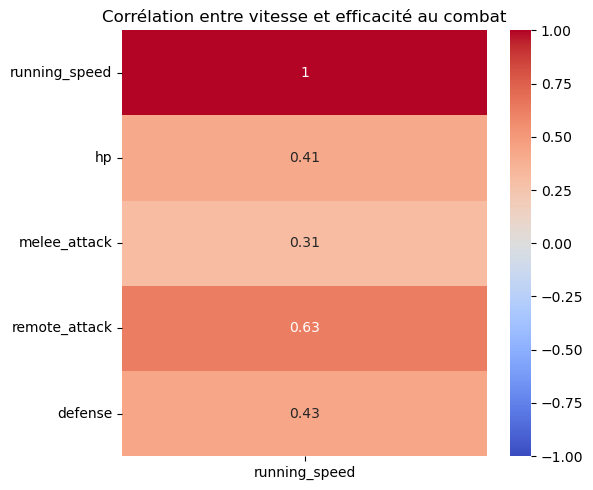

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(corr[["running_speed"]], annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre vitesse et efficacité au combat")
plt.tight_layout()
plt.show()


In [ ]:
# m. Comment former l'équipe la plus équilibrée en combinant des Pals aux attributs complémentaires ? Proposez une équipe équilibrée de 5 Pals.

